[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/notes/notebooks/07-clustering-kmeans.ipynb)


# Machine Learning: Clustering con K-Means

## Colab completo con definiciones claras, datos reales, métricas, gráficos e interpretación

### Objetivo general

Aprender a construir, evaluar e interpretar un modelo de **Clustering con K-Means** utilizando un conjunto de datos real.

### Al finalizar este notebook podrás:

1. Entender qué es aprendizaje no supervisado.
2. Diferenciar clasificación de clustering.
3. Comprender qué es un cluster.
4. Entender cómo funciona K-Means.
5. Saber para qué y en qué casos se utiliza.
6. Trabajar correctamente con escalamiento.
7. Elegir el número apropiado de clusters.
8. Utilizar:
   - Método del Codo
   - Silhouette Score
   - Davies-Bouldin Index
   - Calinski-Harabasz Score
9. Entrenar un modelo `KMeans`.
10. Visualizar clusters mediante PCA.
11. Interpretar centroides.
12. Construir perfiles de los clusters.
13. Asignar una nueva observación a un cluster.
14. Comparar los clusters con etiquetas reales **solo después del entrenamiento**, como análisis externo.

> **Importante:** en clustering no utilizaremos la variable objetivo para entrenar el modelo. El algoritmo debe encontrar grupos únicamente a partir de las características.



# 1. ¿Qué es aprendizaje no supervisado?

En **Machine Learning no supervisado** no proporcionamos al modelo una variable objetivo `y`.

El algoritmo recibe únicamente:

$$
X = \text{variables predictoras}
$$

y busca patrones o estructuras internas.

Algunos problemas no supervisados son:

- Clustering
- Reducción de dimensionalidad
- Detección de anomalías
- Segmentación

La pregunta cambia de:

> “¿Qué clase debo predecir?”

a:

> **“¿Qué grupos naturales existen dentro de los datos?”**



# 2. Clasificación vs Clustering

## Clasificación

Es supervisada.

Tenemos:

- `X`: variables predictoras
- `y`: etiqueta conocida

Ejemplo:

`malignant / benign`

El modelo aprende utilizando las etiquetas.

---

## Clustering

Es no supervisado.

Tenemos:

- `X`: variables
- no utilizamos `y` para entrenar

El modelo intenta descubrir grupos similares.

Ejemplos:

- segmentación de clientes;
- grupos de pacientes;
- perfiles de consumo;
- patrones de comportamiento;
- agrupación de productos;
- agrupación de regiones.



# 3. ¿Qué es un cluster?

Un **cluster** es un grupo de observaciones similares entre sí y diferentes de las observaciones de otros grupos.

Idealmente:

- alta similitud dentro del cluster;
- alta diferencia entre clusters.

Ejemplo conceptual:

Clientes agrupados por:

- ingresos;
- frecuencia de compra;
- gasto;
- antigüedad.

Podríamos descubrir:

- clientes de alto valor;
- clientes ocasionales;
- clientes sensibles al precio;
- clientes nuevos.



# 4. ¿Qué es K-Means?

K-Means es uno de los algoritmos de clustering más utilizados.

Su objetivo es dividir los datos en **K grupos**.

## Funcionamiento simplificado

1. Elegimos `K`.
2. Se crean K centroides iniciales.
3. Cada observación se asigna al centroide más cercano.
4. Se recalculan los centroides.
5. Se repite el proceso hasta estabilizar los grupos.

El algoritmo intenta minimizar la distancia de cada observación respecto al centro de su cluster.



# 5. ¿Qué es un centroide?

Un **centroide** representa el punto central de un cluster.

Si un cluster contiene varias observaciones, el centroide se calcula aproximadamente como el promedio de sus características.

Conceptualmente:

$$
Centroide_j = \text{promedio de las observaciones del cluster } j
$$

Los centroides permiten describir el perfil típico de cada grupo.



# 6. ¿Cuándo se utiliza clustering?

## Marketing
Segmentar clientes.

## Banca
Encontrar perfiles financieros.

## Salud
Explorar perfiles de pacientes.

## Industria
Agrupar patrones de sensores.

## Geografía
Agrupar regiones con características similares.

## Comercio electrónico
Segmentar usuarios por comportamiento.

## Investigación
Descubrir subgrupos dentro de una población.



# 7. Dataset real: Breast Cancer Wisconsin

Utilizaremos el mismo dataset de los ejercicios anteriores.

Pero existe una diferencia fundamental:

> **NO utilizaremos `target` para entrenar K-Means.**

El dataset contiene:

- 569 observaciones
- 30 variables numéricas

Las etiquetas `malignant` y `benign` se conservarán únicamente para un análisis posterior y opcional.

Esto permite estudiar si los clusters encontrados espontáneamente guardan alguna relación con las clases reales.


In [1]:

# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:

# Cargar dataset
data = load_breast_cancer(as_frame=True)

X = data.data.copy()

# Guardamos las etiquetas reales SOLO para análisis posterior
y_real = data.target.copy()

df = X.copy()

print("Dimensiones de X:", X.shape)
print("Número de variables:", X.shape[1])

display(X.head())


Dimensiones de X: (569, 30)
Número de variables: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



# 8. Exploración inicial — EDA

Antes de hacer clustering debemos revisar:

- dimensiones;
- tipos de variables;
- valores faltantes;
- escalas;
- distribuciones;
- posibles valores extremos.

En clustering, las escalas son especialmente importantes.


In [3]:

print("Valores faltantes totales:")
print(X.isna().sum().sum())

print("\nTipos de variables:")
display(X.dtypes.to_frame("dtype").head(10))

print("\nResumen estadístico:")
display(X.describe().T.head(15))


Valores faltantes totales:
0

Tipos de variables:


,dtype
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64



Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.37000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.84000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.24000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.10000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.09587,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.09263,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.06154,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.03350,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.17920,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.06154,0.066120,0.09744



# 9. ¿Por qué debemos escalar antes de K-Means?

K-Means utiliza **distancias**.

Si una variable está medida entre 0 y 1 y otra entre 0 y 10 000, la segunda dominará la distancia.

Ejemplo:

- edad: 20–80
- ingresos: 1 000–20 000 000

Sin escalar, ingresos dominaría el clustering.

Por eso utilizaremos `StandardScaler`.

Después del escalamiento:

- media ≈ 0
- desviación estándar ≈ 1


In [4]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

display(X_scaled_df.head())


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [5]:

# Verificación aproximada
verificacion = pd.DataFrame({
    "Media": X_scaled_df.mean(),
    "Desviación": X_scaled_df.std(ddof=0)
})

display(verificacion.head(10).round(3))


,Media,Desviación
mean radius,-0.0,1.0
mean texture,0.0,1.0
mean perimeter,-0.0,1.0
mean area,-0.0,1.0
mean smoothness,-0.0,1.0
mean compactness,0.0,1.0
mean concavity,0.0,1.0
mean concave points,-0.0,1.0
mean symmetry,0.0,1.0
mean fractal dimension,0.0,1.0



# 10. ¿Cómo elegir el número correcto de clusters?

Esta es una de las preguntas más importantes.

No debemos escoger `K=3` o `K=5` arbitrariamente.

Utilizaremos varias herramientas:

1. **Método del Codo**
2. **Silhouette Score**
3. **Davies-Bouldin Index**
4. **Calinski-Harabasz Score**

No existe una métrica perfecta.

La decisión debe combinar:

**métricas + gráficos + interpretabilidad del problema**



# 11. Método del Codo — Elbow Method

K-Means calcula una medida llamada **inertia**.

La inertia representa la suma de las distancias cuadráticas entre cada observación y su centroide.

### Interpretación

- inertia menor = clusters más compactos;
- al aumentar K, inertia siempre disminuye.

Por eso buscamos un punto donde la mejora empieza a ser mucho menor.

Ese punto se conoce como **codo**.


In [6]:

ks = range(2, 11)

inercias = []
silhouettes = []
davies = []
calinski = []

for k in ks:

    modelo = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    clusters = modelo.fit_predict(X_scaled)

    inercias.append(modelo.inertia_)
    silhouettes.append(
        silhouette_score(X_scaled, clusters)
    )
    davies.append(
        davies_bouldin_score(X_scaled, clusters)
    )
    calinski.append(
        calinski_harabasz_score(X_scaled, clusters)
    )


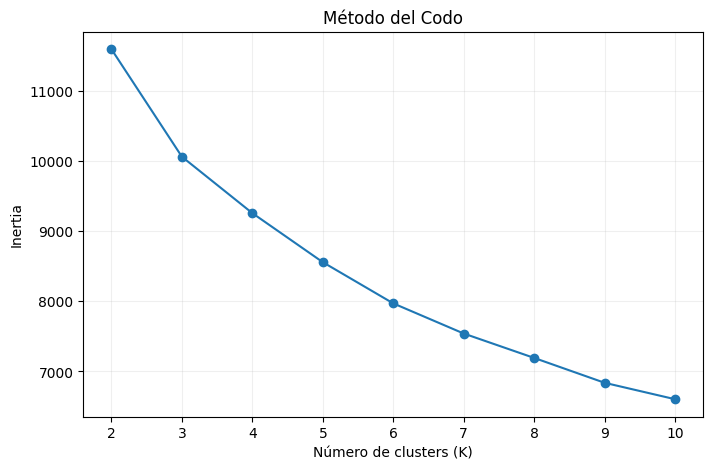

In [7]:

# Gráfico del Codo
plt.figure(figsize=(8,5))
plt.plot(list(ks), inercias, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.title("Método del Codo")
plt.grid(alpha=0.2)
plt.show()



# 12. Silhouette Score

Silhouette mide qué tan bien ubicada está una observación dentro de su cluster.

Su rango teórico es:

$$
-1 \leq Silhouette \leq 1
$$

Interpretación aproximada:

- cercano a 1 → clusters bien separados;
- cercano a 0 → clusters solapados;
- negativo → posible asignación incorrecta.

### Regla

**Mayor Silhouette = mejor separación.**


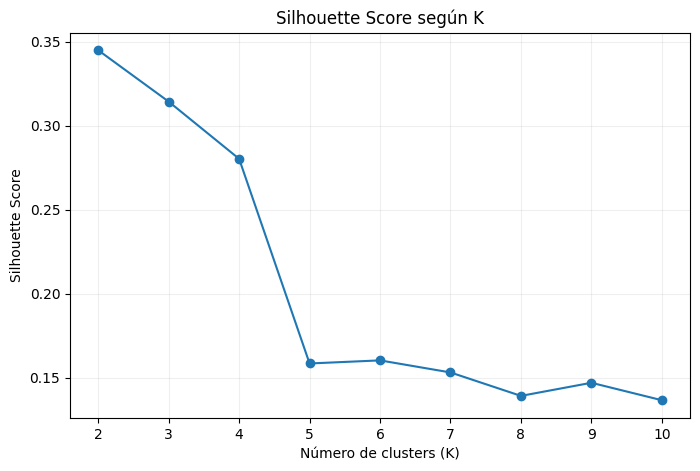

In [8]:

plt.figure(figsize=(8,5))
plt.plot(list(ks), silhouettes, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score según K")
plt.grid(alpha=0.2)
plt.show()



# 13. Davies-Bouldin Index

Evalúa similitud entre clusters.

### Regla

**Menor Davies-Bouldin = mejor.**

Un valor pequeño indica:

- clusters compactos;
- clusters separados.


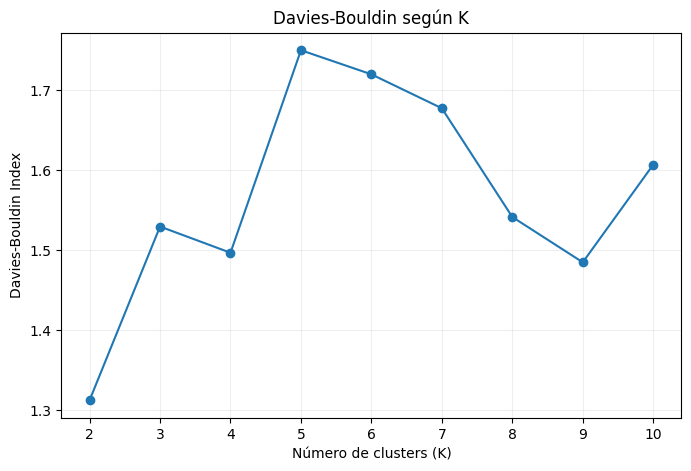

In [9]:

plt.figure(figsize=(8,5))
plt.plot(list(ks), davies, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin según K")
plt.grid(alpha=0.2)
plt.show()



# 14. Calinski-Harabasz Score

Compara:

- separación entre clusters;
- compactación dentro de clusters.

### Regla

**Mayor Calinski-Harabasz = mejor.**


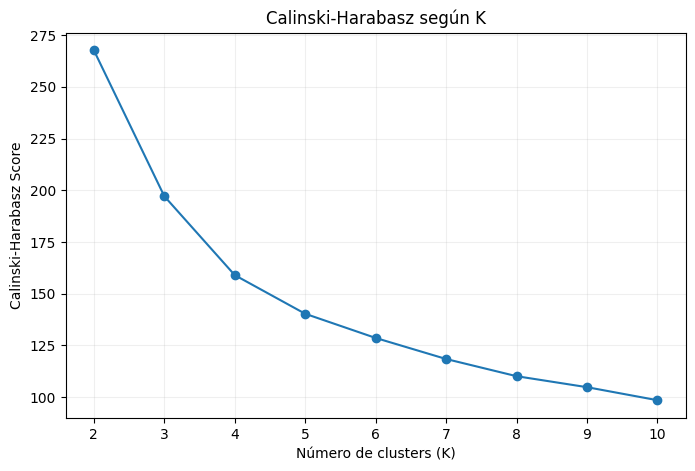

In [10]:

plt.figure(figsize=(8,5))
plt.plot(list(ks), calinski, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz según K")
plt.grid(alpha=0.2)
plt.show()



# 15. Tabla comparativa de K

Vamos a poner todas las métricas juntas.


In [11]:

tabla_k = pd.DataFrame({
    "K": list(ks),
    "Inertia": inercias,
    "Silhouette": silhouettes,
    "Davies_Bouldin": davies,
    "Calinski_Harabasz": calinski
})

display(tabla_k.round(4))


,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,11595.4615,0.3450,1.3123,267.6964
1,3,10061.7978,0.3144,1.5294,197.1140
2,4,9257.3625,0.2803,1.4967,158.9416
3,5,8557.7275,0.1585,1.7498,140.2511
4,6,7970.2638,0.1604,1.7197,128.5566
5,7,7540.3187,0.1532,1.6772,118.3787
6,8,7192.1920,0.1392,1.5413,110.0688
7,9,6837.6289,0.1470,1.4847,104.7536
8,10,6603.4044,0.1367,1.6067,98.4480



# 16. Selección automática inicial de K

Usaremos **Silhouette Score** como criterio principal automático.

Después verificaremos si:

- Davies-Bouldin;
- Calinski-Harabasz;
- el gráfico del codo;

son razonablemente consistentes.

Esto no significa que Silhouette sea siempre la única métrica válida.


In [12]:

mejor_fila = tabla_k.loc[
    tabla_k["Silhouette"].idxmax()
]

mejor_k = int(mejor_fila["K"])

print("K seleccionado inicialmente:", mejor_k)
print("Silhouette:", round(mejor_fila["Silhouette"], 4))
print("Davies-Bouldin:", round(mejor_fila["Davies_Bouldin"], 4))
print("Calinski-Harabasz:", round(mejor_fila["Calinski_Harabasz"], 2))


K seleccionado inicialmente: 2
Silhouette: 0.345
Davies-Bouldin: 1.3123
Calinski-Harabasz: 267.7



# 17. Entrenamiento final de K-Means

Entrenaremos K-Means con el valor de K seleccionado.


In [13]:

kmeans = KMeans(
    n_clusters=mejor_k,
    random_state=RANDOM_STATE,
    n_init=50
)

clusters = kmeans.fit_predict(X_scaled)

df_cluster = X.copy()
df_cluster["Cluster"] = clusters

print("Número de clusters:", mejor_k)

display(
    df_cluster["Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Cantidad")
)


Número de clusters: 2


,Cantidad
Cluster,
0,189
1,380



# 18. Métricas finales del clustering

Evaluaremos:

- Silhouette
- Davies-Bouldin
- Calinski-Harabasz
- Inertia


In [14]:

silhouette_final = silhouette_score(
    X_scaled,
    clusters
)

davies_final = davies_bouldin_score(
    X_scaled,
    clusters
)

calinski_final = calinski_harabasz_score(
    X_scaled,
    clusters
)

inertia_final = kmeans.inertia_

metricas_finales = pd.DataFrame({
    "Métrica": [
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz",
        "Inertia"
    ],
    "Resultado": [
        silhouette_final,
        davies_final,
        calinski_final,
        inertia_final
    ]
})

display(metricas_finales.round(4))


,Métrica,Resultado
0,Silhouette,0.3450
1,Davies-Bouldin,1.3123
2,Calinski-Harabasz,267.6964
3,Inertia,11595.4615



# 19. Tamaño de los clusters

Es importante verificar si:

- un cluster contiene casi todos los datos;
- existen clusters extremadamente pequeños;
- los grupos tienen tamaños razonables.

Un cluster pequeño no es necesariamente incorrecto, pero merece análisis.


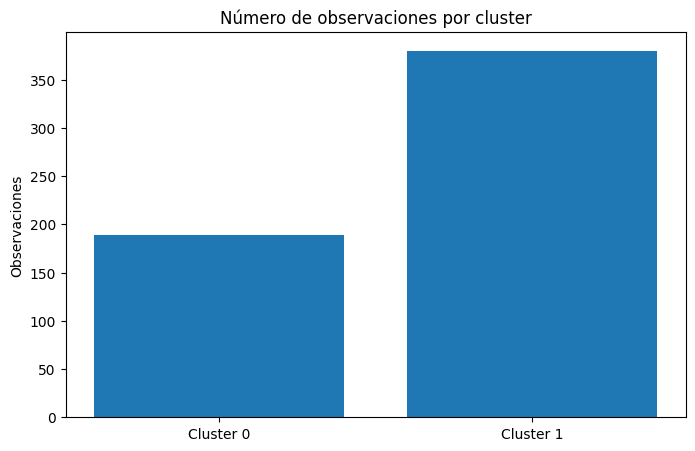

In [15]:

tamano_clusters = (
    df_cluster["Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))
plt.bar(
    [f"Cluster {i}" for i in tamano_clusters.index],
    tamano_clusters.values
)
plt.title("Número de observaciones por cluster")
plt.ylabel("Observaciones")
plt.show()



# 20. PCA para visualizar los clusters

Tenemos 30 variables.

No podemos representar 30 dimensiones directamente.

Utilizaremos **PCA** únicamente para visualizar los clusters en 2 dimensiones.

> Importante: K-Means fue entrenado con las 30 variables escaladas. PCA aquí se utiliza para visualización.


In [16]:

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters
})

print(
    "Varianza explicada por PC1 + PC2:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)


Varianza explicada por PC1 + PC2: 63.24 %


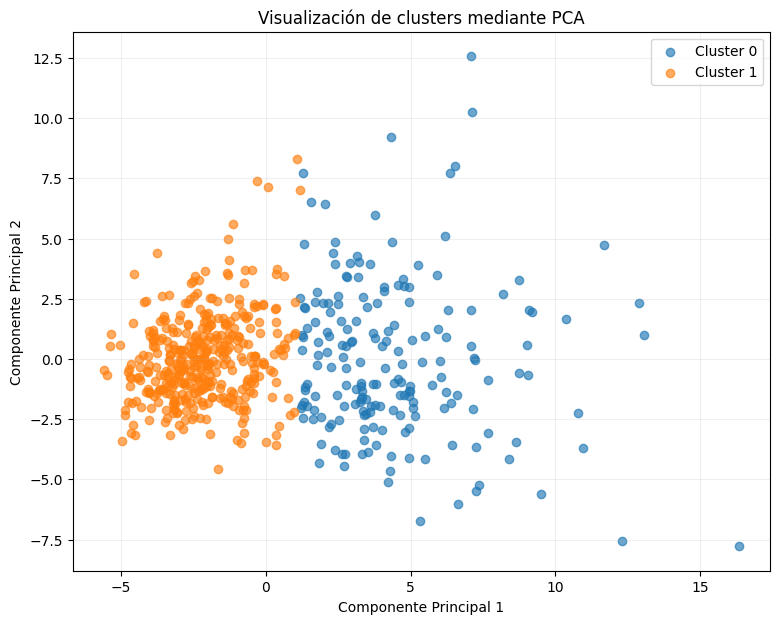

In [17]:

plt.figure(figsize=(9,7))

for cluster in sorted(df_pca["Cluster"].unique()):
    subset = df_pca[
        df_pca["Cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.65,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Visualización de clusters mediante PCA")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



# 21. ¿Qué son los centroides del modelo?

K-Means almacena un centroide para cada cluster.

Como entrenamos con datos estandarizados, los centroides inicialmente están en escala estándar.

Los convertiremos a las unidades originales para facilitar la interpretación.


In [18]:

centroides_scaled = kmeans.cluster_centers_

centroides_originales = scaler.inverse_transform(
    centroides_scaled
)

df_centroides = pd.DataFrame(
    centroides_originales,
    columns=X.columns
)

df_centroides.index = [
    f"Cluster {i}"
    for i in range(mejor_k)
]

display(df_centroides.iloc[:, :10].round(3))


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
Cluster 0,17.557,21.359,116.408,993.67,0.105,0.158,0.180,0.094,0.198,0.065
Cluster 1,12.422,18.260,79.814,486.39,0.092,0.078,0.044,0.026,0.173,0.062



# 22. Perfil promedio de cada cluster

Otra forma intuitiva de entender los grupos es calcular el promedio de las variables dentro de cada cluster.


In [19]:

perfil_clusters = (
    df_cluster
    .groupby("Cluster")
    .mean()
)

display(
    perfil_clusters.iloc[:, :10].round(3)
)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
Cluster,,,,,,,,,,
0,17.557,21.359,116.408,993.67,0.105,0.158,0.180,0.094,0.198,0.065
1,12.422,18.260,79.814,486.39,0.092,0.078,0.044,0.026,0.173,0.062



# 23. Variables que más diferencian los clusters

Compararemos la variación de los centroides estandarizados.

Las variables cuyos centroides cambian más entre clusters son candidatas a ser importantes para describir los grupos.


In [20]:

centroides_std_df = pd.DataFrame(
    centroides_scaled,
    columns=X.columns
)

variacion_centroides = (
    centroides_std_df
    .max(axis=0)
    - centroides_std_df.min(axis=0)
).sort_values(ascending=False)

top_variables = variacion_centroides.head(10)

display(
    top_variables
    .to_frame("Diferencia_entre_centroides")
)


,Diferencia_entre_centroides
mean concave points,1.743808
worst concave points,1.716300
mean concavity,1.706146
worst perimeter,1.596151
worst concavity,1.563700
worst radius,1.557388
mean compactness,1.528358
mean perimeter,1.507303
worst area,1.502091
mean radius,1.458401


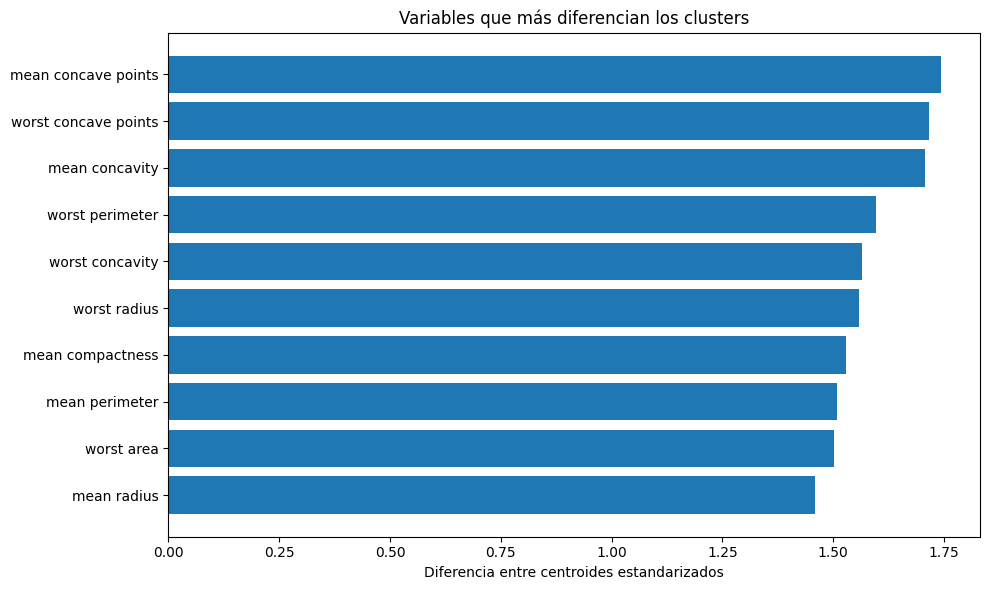

In [21]:

plt.figure(figsize=(10,6))
plt.barh(
    top_variables.index[::-1],
    top_variables.values[::-1]
)
plt.title("Variables que más diferencian los clusters")
plt.xlabel("Diferencia entre centroides estandarizados")
plt.tight_layout()
plt.show()



# 24. Silhouette por observación

El Silhouette promedio resume el clustering.

Pero también podemos analizar cada observación.

Valores bajos o negativos pueden indicar:

- casos fronterizos;
- posible solapamiento;
- observaciones difíciles de asignar.


In [22]:

silhouette_individual = silhouette_samples(
    X_scaled,
    clusters
)

df_silhouette = pd.DataFrame({
    "Cluster": clusters,
    "Silhouette": silhouette_individual
})

display(
    df_silhouette
    .groupby("Cluster")["Silhouette"]
    .agg(["mean", "min", "max", "count"])
    .round(4)
)


,mean,min,max,count
Cluster,,,,
0,0.1477,-0.1555,0.3720,189
1,0.4431,0.0674,0.5829,380


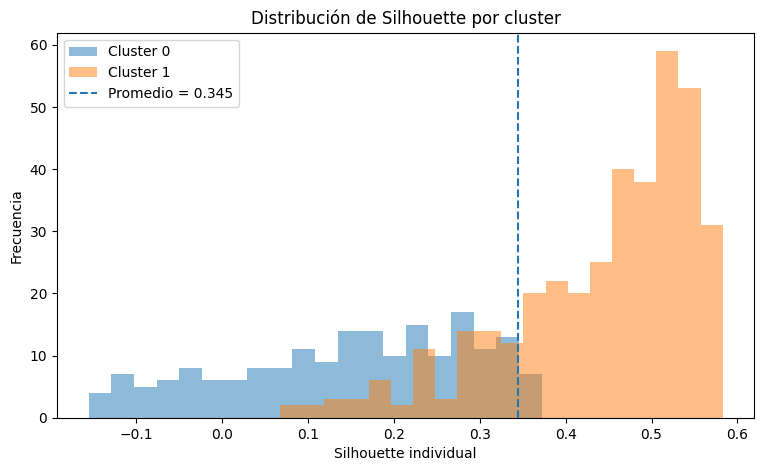

In [23]:

plt.figure(figsize=(9,5))

for cluster in sorted(df_silhouette["Cluster"].unique()):
    valores = df_silhouette.loc[
        df_silhouette["Cluster"] == cluster,
        "Silhouette"
    ]

    plt.hist(
        valores,
        bins=20,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.axvline(
    silhouette_final,
    linestyle="--",
    label=f"Promedio = {silhouette_final:.3f}"
)

plt.xlabel("Silhouette individual")
plt.ylabel("Frecuencia")
plt.title("Distribución de Silhouette por cluster")
plt.legend()
plt.show()



# 25. Asignar una nueva observación a un cluster

K-Means también puede asignar nuevas observaciones.

Debemos aplicar exactamente el mismo escalamiento utilizado durante el entrenamiento.


In [24]:

# Ejemplo académico: perfil mediano del dataset
nueva_observacion = X.median().to_frame().T

# Escalar con el scaler ya entrenado
nueva_scaled = scaler.transform(
    nueva_observacion
)

cluster_nuevo = kmeans.predict(
    nueva_scaled
)[0]

print(
    "La nueva observación pertenece al Cluster:",
    cluster_nuevo
)

display(nueva_observacion.iloc[:, :10])


La nueva observación pertenece al Cluster: 1


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
0,13.37,18.84,86.24,551.1,0.09587,0.09263,0.06154,0.0335,0.1792,0.06154



# 26. ¿Cómo interpretar una predicción de clustering?

En clasificación decíamos:

> “Esta observación pertenece a la clase benign.”

En clustering debemos decir:

> **“Según sus características, esta observación es más similar al Cluster X.”**

El cluster no tiene automáticamente un significado clínico, comercial o biológico.

Ese significado debe construirse mediante:

- análisis del perfil;
- conocimiento del dominio;
- variables características;
- validación externa.



# 27. Análisis externo con las etiquetas reales

Hasta ahora **NO utilizamos `target` para entrenar K-Means**.

Ahora, únicamente como análisis posterior, podemos preguntar:

> ¿Los clusters encontrados tienen alguna relación con las clases malignant / benign?

Esto NO convierte el clustering en clasificación.

Es simplemente una evaluación externa.


In [25]:

tabla_cluster_clase = pd.crosstab(
    clusters,
    y_real,
    rownames=["Cluster"],
    colnames=["Clase_real"]
)

tabla_cluster_clase.columns = [
    data.target_names[i]
    for i in tabla_cluster_clase.columns
]

display(tabla_cluster_clase)


,malignant,benign
Cluster,,
0,175,14
1,37,343


In [26]:

# Porcentajes dentro de cada cluster
tabla_cluster_pct = (
    tabla_cluster_clase
    .div(
        tabla_cluster_clase.sum(axis=1),
        axis=0
    )
    * 100
)

display(tabla_cluster_pct.round(2))


,malignant,benign
Cluster,,
0,92.59,7.41
1,9.74,90.26


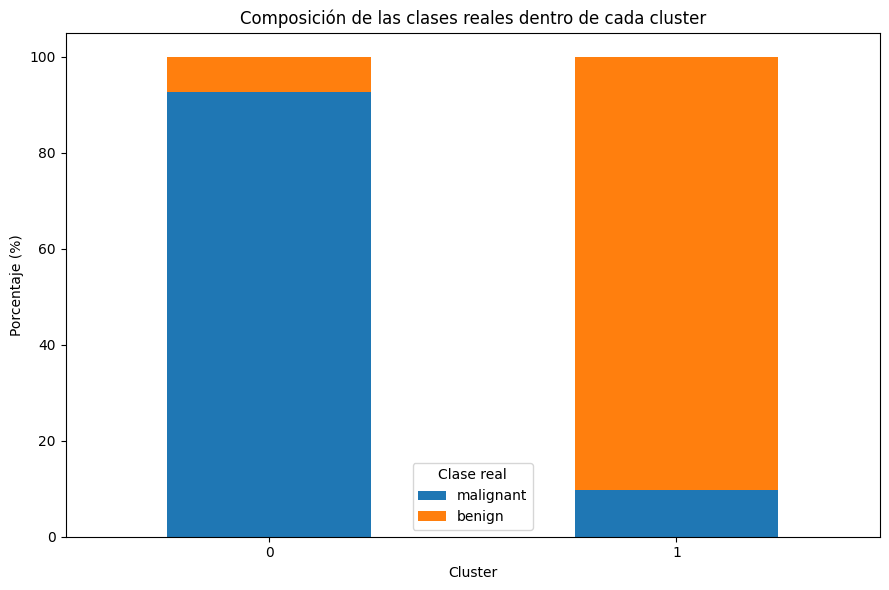

In [27]:

# Gráfico composición real dentro de cada cluster
tabla_cluster_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(9,6)
)

plt.ylabel("Porcentaje (%)")
plt.title("Composición de las clases reales dentro de cada cluster")
plt.xticks(rotation=0)
plt.legend(title="Clase real")
plt.tight_layout()
plt.show()



# 28. Métricas externas: ARI y NMI

Cuando tenemos etiquetas reales, podemos comparar clusters con esas etiquetas.

## Adjusted Rand Index — ARI

- cercano a 1 → alta coincidencia;
- cercano a 0 → similar a una agrupación aleatoria.

## Normalized Mutual Information — NMI

Mide cuánta información comparten los clusters y las clases.

- cercano a 1 → alta relación;
- cercano a 0 → poca relación.

> Estas métricas solo son posibles porque en este dataset conocemos etiquetas externas. En un problema real de clustering muchas veces no existirán.


In [28]:

ari = adjusted_rand_score(
    y_real,
    clusters
)

nmi = normalized_mutual_info_score(
    y_real,
    clusters
)

print("Adjusted Rand Index:", round(ari, 4))
print("Normalized Mutual Information:", round(nmi, 4))


Adjusted Rand Index: 0.6707
Normalized Mutual Information: 0.5546



# 29. Importante: Cluster ≠ Clase

Aunque un cluster pueda contener principalmente casos benignos o malignos:

> **No debemos tratar el número del cluster como un diagnóstico.**

Los clusters son grupos matemáticos encontrados a partir de similitud.

Sus etiquetas:

- Cluster 0
- Cluster 1
- Cluster 2

no tienen significado por sí mismas.

El significado se obtiene después de analizar sus características.



# 30. ¿Qué métricas usar si NO tengo etiquetas reales?

En clustering normalmente no tenemos `y`.

Por eso utilizamos métricas internas:

## Silhouette
Mayor es mejor.

## Davies-Bouldin
Menor es mejor.

## Calinski-Harabasz
Mayor es mejor.

## Inertia
Menor es mejor, pero siempre disminuye al aumentar K.

Por eso la elección de K debe combinar múltiples criterios.



# 31. Limitaciones de K-Means

K-Means funciona mejor cuando:

- los clusters tienen forma aproximadamente esférica;
- las variables son numéricas;
- las escalas están controladas;
- los grupos tienen densidades parecidas.

Puede funcionar mal cuando:

- existen clusters con formas complejas;
- hay muchos outliers;
- los grupos tienen densidades muy diferentes;
- usamos variables categóricas sin tratamiento adecuado.

En esos casos podemos estudiar otros algoritmos.



# 32. Otros métodos de clustering

## Hierarchical Clustering
Construye una jerarquía de grupos.

## DBSCAN
Detecta clusters por densidad y puede identificar ruido.

## Gaussian Mixture Models
Permite pertenencia probabilística.

## HDBSCAN
Extiende clustering por densidad.

## K-Medoids
Puede ser más robusto frente a outliers que K-Means.



# 33. Errores comunes

1. Elegir K arbitrariamente.
2. No escalar variables.
3. Interpretar clusters como clases reales.
4. Evaluar únicamente con inertia.
5. Ignorar Silhouette.
6. No analizar el tamaño de los clusters.
7. No estudiar centroides.
8. Utilizar la variable objetivo para crear los clusters.
9. Pensar que cluster 0 significa “peor” que cluster 1.
10. Asumir causalidad por diferencias entre grupos.



# 34. Flujo recomendado en un proyecto real

**Problema → seleccionar variables → EDA → limpieza → escalamiento → probar varios K → Elbow → Silhouette → Davies-Bouldin → Calinski-Harabasz → elegir K → entrenar K-Means → analizar tamaños → PCA → centroides → perfiles → interpretar → validar con conocimiento del dominio**



# 35. Conclusiones

En este notebook aprendimos que:

- clustering es aprendizaje no supervisado;
- no utilizamos `y` para entrenar;
- K-Means divide los datos en K grupos;
- el escalamiento es fundamental;
- no debemos elegir K arbitrariamente;
- Silhouette, Davies-Bouldin y Calinski-Harabasz ayudan a evaluar;
- PCA permite visualizar clusters de alta dimensión;
- los centroides ayudan a interpretar los grupos;
- podemos asignar nuevas observaciones;
- las etiquetas reales solo pueden utilizarse posteriormente como validación externa;
- Cluster no significa automáticamente Clase.

La pregunta correcta no es:

> “¿Qué clase predijo K-Means?”

sino:

> **“¿Qué grupos naturales encontró el algoritmo y qué características los diferencian?”**



# 36. Referencias

- Scikit-learn — KMeans  
  https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

- Scikit-learn — Clustering  
  https://scikit-learn.org/stable/modules/clustering.html

- Scikit-learn — Silhouette Score  
  https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

- Scikit-learn — Davies-Bouldin Score  
  https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html

- Scikit-learn — PCA  
  https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

- Scikit-learn — Breast Cancer Wisconsin  
  https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
